In [ ]:
##Tema 02 laborator

In [ ]:
#Exemplu titanic seaborn

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
#importuri

In [ ]:
#Initializare

In [ ]:
sns.set_theme(style='whitegrid', palette='muted')
titanic = sns.load_dataset('titanic')

In [ ]:
# --- Explorare inițială ---
print("=== Informații generale ===")
print(f"Dimensiune: {titanic.shape}")
print(f"\nValori lipsă:\n{titanic.isnull().sum()[titanic.isnull().sum() > 0]}")
print(f"\nRata globală de supraviețuire: {titanic['survived'].mean():.1%}")

=== Informații generale ===
Dimensiune: (891, 15)

Valori lipsă:
age            177
embarked         2
deck           688
embark_town      2
dtype: int64

Rata globală de supraviețuire: 38.4%


In [ ]:
# --- Rata de supraviețuire per sex ---
print("\n=== Rata de supraviețuire per sex ===")
rata_sex = titanic.groupby('sex', observed=True)['survived'].mean().round(3)
print(rata_sex)


=== Rata de supraviețuire per sex ===
sex
female    0.742
male      0.189
Name: survived, dtype: float64


In [ ]:
# --- Rata de supraviețuire per clasă ---
print("\n=== Rata de supraviețuire per clasă ===")
rata_clasa = titanic.groupby('class', observed=True)['survived'].mean().round(3)
print(rata_clasa)


=== Rata de supraviețuire per clasă ===
class
First     0.630
Second    0.473
Third     0.242
Name: survived, dtype: float64


In [ ]:
# --- Tabel încrucișat: supraviețuire per sex și clasă ---
# pivot_table creează un tabel de sinteză cu valorile dintr-o coloană
# agregate în funcție de alte două coloane (index și columns)
print("\n=== Rata de supraviețuire per sex și clasă ===")
pivot = titanic.pivot_table(values='survived',
index='class',
columns='sex',
aggfunc='mean',
observed=True).round(3)
print(pivot)


=== Rata de supraviețuire per sex și clasă ===
sex     female   male
class                
First    0.968  0.369
Second   0.921  0.157
Third    0.500  0.135


Text(0.5, 0.98, 'Analiza supraviețuirii — Dataset Titanic')

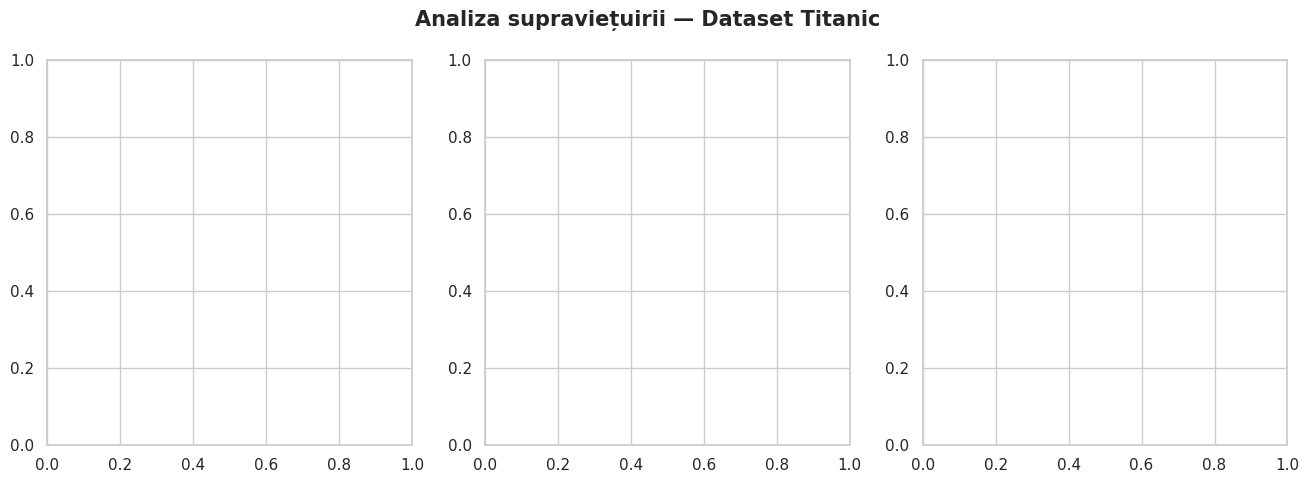

In [ ]:
# --- Vizualizare ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Analiza supraviețuirii — Dataset Titanic', fontsize=15,
fontweight='bold')

In [ ]:
# Subplot 1: Rata de supraviețuire per sex
sns.barplot(data=titanic, x='sex', y='survived', hue='sex', ax=axes[0],
errorbar='ci', palette=['#e74c3c', '#3498db'], legend=False)
axes[0].set_title('Supraviețuire per sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Rată de supraviețuire')
axes[0].set_ylim(0, 1)

(0.0, 1.0)

In [ ]:
# Subplot 2: Rata de supraviețuire per clasă
sns.barplot(data=titanic, x='class', y='survived', hue='class', ax=axes[1],
errorbar='ci', order=['First', 'Second', 'Third'],
palette='Blues_d', legend=False)
axes[1].set_title('Supraviețuire per clasă')
axes[1].set_xlabel('Clasă')
axes[1].set_ylabel('Rată de supraviețuire')
axes[1].set_ylim(0, 1)

(0.0, 1.0)

In [ ]:
# Subplot 3: Rata per sex și clasă — parametrul hue colorează barele per sex
sns.barplot(data=titanic, x='class', y='survived', hue='sex',
ax=axes[2], errorbar='ci',
order=['First', 'Second', 'Third'],
palette=['#e74c3c', '#3498db'])
axes[2].set_title('Supraviețuire per clasă și sex')
axes[2].set_xlabel('Clasă')
axes[2].set_ylabel('Rată de supraviețuire')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Sex')
plt.tight_layout()
plt.savefig('titanic_analiza.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nConcluzie: Femeile și pasagerii din clasa I au avut rate de supraviețuire semnificativ mai mari,")
print("reflectând atât politica 'femei și copii primii', cât și privilegiile de clasă socială.")

<Figure size 640x480 with 0 Axes>


Concluzie: Femeile și pasagerii din clasa I au avut rate de supraviețuire semnificativ mai mari,
reflectând atât politica 'femei și copii primii', cât și privilegiile de clasă socială.


nConcluzie: Femeile și pasagerii din clasa I au avut rate de supraviețuire semnificativ mai mari